# Reggression in scikit learn

In [92]:
# import liberaries
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns   

# oother liberaries
from  sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [61]:
# import data
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [62]:
df_linear = df[['age', 'fare']]
df_linear.head()

,age,fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


In [63]:
# simple linear regression
X= df[['age']]
y= df['fare']
# X ko hamesha 2D array me convert krain ge wrrna wo id (series) me chala jayega

In [64]:
X.isnull().sum()/len(X)*100

age    19.86532
dtype: float64

In [65]:
y.isnull().sum()/len(X)*100

np.float64(0.0)

In [66]:
# X.age.fillna(value = X['age'].mean(), inplace=True) 

X[['age']] = X[['age']].fillna(value=X['age'].mean(), inplace=False) 

C:\Users\premier\AppData\Local\Temp\ipykernel_7272\2757507428.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[['age']] = X[['age']].fillna(value=X['age'].mean(), inplace=False)


In [67]:
X

,age
0,22.000000
1,38.000000
2,26.000000
3,35.000000
4,35.000000
...,...
886,27.000000
887,19.000000
888,29.699118
889,26.000000


In [68]:
X.isnull().sum()/len(X)*100

age    0.0
dtype: float64

In [69]:
X.shape, y.shape
# null values ko deal krne se dono ki shape same ho gayi hai

((891, 1), (891,))

y series ha is lie aik ha (891) , X 2d ha islia to dimensions(891, 1)

In [70]:
df_linear.age.fillna(value=df_linear['age'].mean(), inplace=True)

C:\Users\premier\AppData\Local\Temp\ipykernel_7272\3808235274.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_linear.age.fillna(value=df_linear['age'].mean(), inplace=True)
C:\Users\premier\AppData\Local\Temp\ipykernel_7272\3808235274.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_linear.age.fillna(value=df_linear['age'].mean(),

In [71]:
df_linear.isnull().sum()/len(df)*100

age     0.0
fare    0.0
dtype: float64

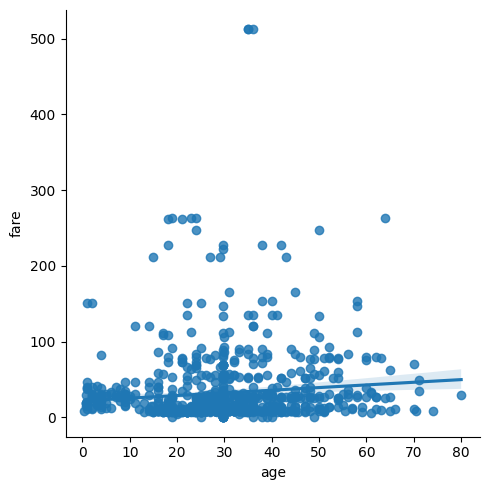

In [72]:
# plot to chexk X or y kia ha
sns.lmplot(x='age', y='fare', data=df_linear)

<Axes: ylabel='age'>

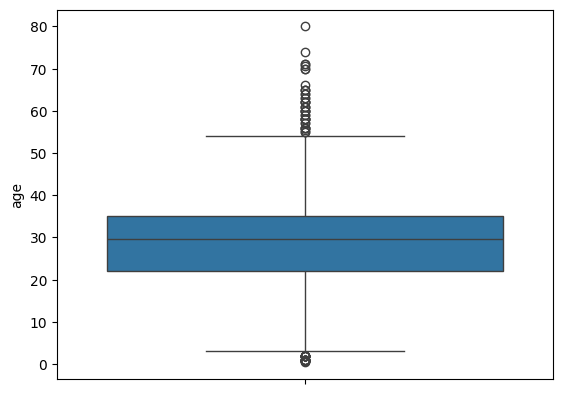

In [73]:
sns.boxplot(y='age', data=df_linear)

In [74]:
df_linear = df_linear[(df_linear['age']>8) & (df_linear['age']<50)]

removing outliers without any formula just my eleminating or limits

<Axes: ylabel='age'>

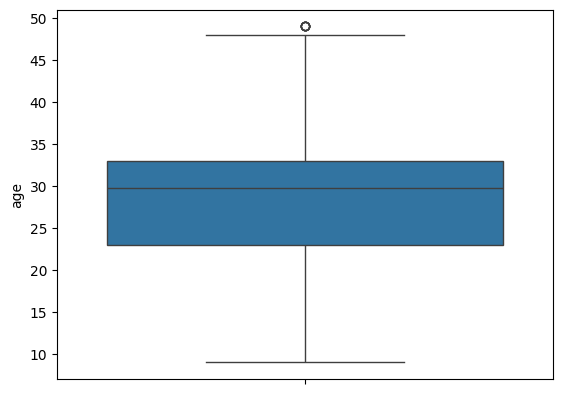

In [75]:
sns.boxplot(y='age', data=df_linear)

<Axes: ylabel='fare'>

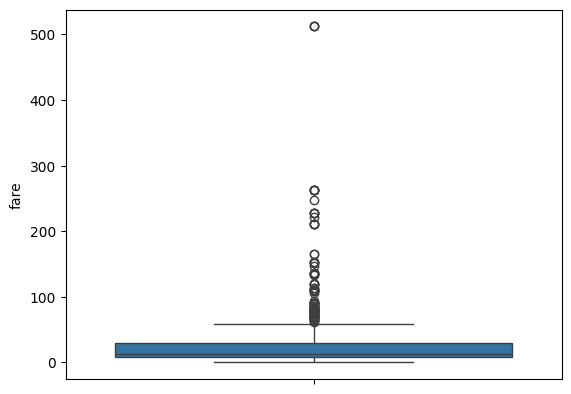

In [76]:
sns.boxplot(y='fare', data=df_linear)

In [77]:
df_linear['fare'].min

<bound method Series.min of 0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: fare, Length: 763, dtype: float64>

In [78]:
df_linear = df_linear[(df_linear['fare']>1) & (df_linear['fare']<80)]

<Axes: ylabel='fare'>

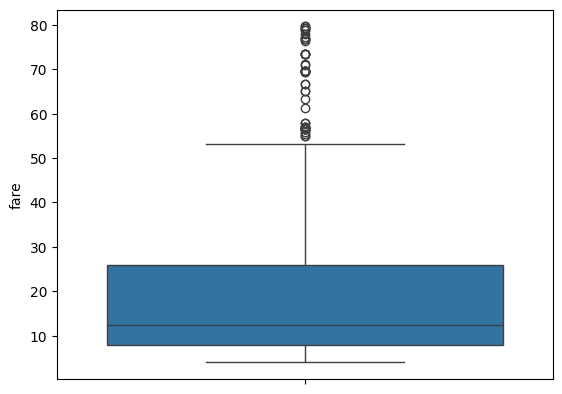

In [79]:
sns.boxplot(y='fare', data=df_linear)

In [80]:
X = df_linear[['age']]
y = df_linear['fare']

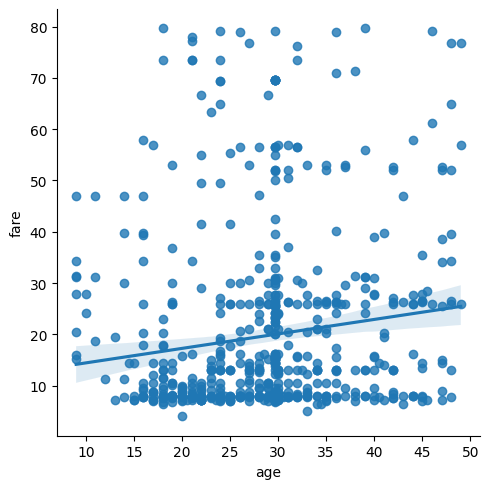

In [81]:
sns.lmplot(x='age', y='fare', data=df_linear)

In [82]:
# model bulate hain
model = LinearRegression()

#train the model
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [83]:
# predicting fare using age 
model.predict([[25]])

C:\Users\premier\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([18.6671588])

In [84]:
# model evaluation with metrics
# r2
# mean squared error
# MAE
# RMSE

# yehi 4 metrices btate hain ki prediction sahi hai ya nahi


In [85]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [86]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((548, 1), (137, 1), (548,), (137,))

In [87]:
# model
model = LinearRegression()

# train the model
model.fit(X_train, y_train)

#prediction
predictions = model.predict(X_test)


<Axes: xlabel='fare'>

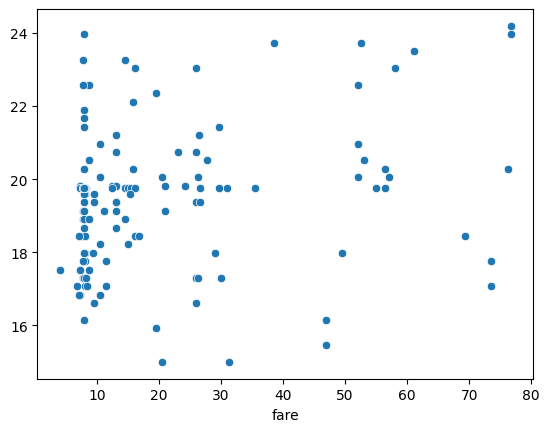

In [88]:

# compare
sns.scatterplot(x = y_test,y =  predictions)

iski accuracy thek ni ha linear line ni ban rahi (quke sub kush ni hain )

In [89]:
model.score(X_test, y_test)

0.03317423975231637

In [98]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
# RMSE = mean_squared_error(y_test, predictions, squared=False)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

Mean Absolute Error: 13.441790799940476
Mean Squared Error: 321.44892077000156
R-squared Score: 0.03317423975231637


In [99]:
import numpy as np
RMSE = np.sqrt(mse)
print(f"Root Mean Squared Error: {RMSE}")

Root Mean Squared Error: 17.928996647051992


In [1]:
import sys
print(sys.version)

3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]


In [2]:
3 + 2 * 2

7